# Model Evaluation Notebook

This notebook provides comprehensive evaluation of the trained predictive maintenance model using the `inverter_predictive_maintenance` package.

## Overview
- Load and evaluate trained CNN-LSTM model
- Apply Platt scaling for probability calibration
- Generate comprehensive evaluation metrics
- Visualize model performance
- Apply post-processing smoothing techniques


In [1]:
# Import required packages
import sys
import os
import pandas as pd
import numpy as np
import torch
import json
import pickle
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path to import the package
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))

# Import from the inverter_predictive_maintenance package
from inverter_predictive_maintenance import (
    InverterTimeSeriesDataset,
    CNNLSTMModel,
    get_logits_and_labels,
    generate_report,
    evaluate_model,
    cal_topK_metrics,
    smooth_by_consecutive,
    plot_outputs_distribution,
    plot_precision_recall
)

# Import additional visualization functions directly from modules
from inverter_predictive_maintenance.visualize.training import (
    plot_roc_curve,
    plot_confusion_matrix
)

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


✅ All imports successful!
PyTorch version: 2.8.0+cu126
Device available: CUDA


## Configuration and Setup

Load configuration parameters and set up device for model evaluation.


In [2]:
# Load configuration parameters
with open("../config/dataset_parameters.json", "r") as f:
    dataset_parameters = json.load(f)
with open("../config/model_parameters.json", "r") as f:
    model_parameters = json.load(f)

# Extract key parameters
feature_cols = dataset_parameters["feature_cols"]
window_size = model_parameters["window_size"]
normal_stride = model_parameters["normal_stride"]

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Print configuration summary
print(f"Feature columns: {len(feature_cols)}")
print(f"Window size: {window_size}")
print(f"Normal stride: {normal_stride}")
print(f"Model parameters: {model_parameters['model_params']}")


Using device: cuda
Feature columns: 21
Window size: 336
Normal stride: 12
Model parameters: {'num_features': 21, 'cnn_out_channels': 32, 'lstm_hidden_size': 64, 'lstm_layers': 2, 'dropout': 0.5}


## Data Loading

Load the train, validation, and test datasets and create DataLoaders for evaluation.


In [3]:
# Load datasets
print("Loading datasets...")
train_df = pd.read_csv('../dataset/train_data.csv')
val_df = pd.read_csv('../dataset/val_data.csv')
test_df = pd.read_csv('../dataset/test_data.csv')

print(f"Train dataset shape: {train_df.shape}")
print(f"Validation dataset shape: {val_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

# Create datasets using the package
train_ds = InverterTimeSeriesDataset.from_dataframe(
    train_df, feature_cols, window_size=window_size, stride=normal_stride
)
val_ds = InverterTimeSeriesDataset.from_dataframe(
    val_df, feature_cols, window_size=window_size, stride=normal_stride
)
test_ds = InverterTimeSeriesDataset.from_dataframe(
    test_df, feature_cols, window_size=window_size, stride=normal_stride
)

print(f"Train dataset samples: {len(train_ds)}")
print(f"Validation dataset samples: {len(val_ds)}")
print(f"Test dataset samples: {len(test_ds)}")

# Create DataLoaders
batch_size = 1024
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print("✅ Datasets and DataLoaders created successfully!")


Loading datasets...
Train dataset shape: (550223, 24)
Validation dataset shape: (141403, 24)
Test dataset shape: (146185, 24)


Processing devices: 100%|██████████| 16/16 [00:00<00:00, 101.44it/s]


Train dataset samples: 42904
Validation dataset samples: 11270
Test dataset samples: 10979
✅ Datasets and DataLoaders created successfully!


## Model Loading

Load the trained CNN-LSTM model and Platt scaler for probability calibration.


In [24]:
# Load the trained model
print("Loading trained model...")
model = CNNLSTMModel(
    num_features=len(feature_cols),
    lstm_layers=model_parameters['model_params']['lstm_layers']
)

# Load model weights
model_path = r'..\model\best_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print(f"✅ Model loaded from: {model_path}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Load Platt scaler for probability calibration
print("Loading Platt scaler...")
platt_scaler_path = '../model/platt_scaler.pkl'
platt_scaler = pickle.load(open(platt_scaler_path, "rb"))
print(f"✅ Platt scaler loaded from: {platt_scaler_path}")


Loading trained model...
✅ Model loaded from: ..\model\best_model.pth
Model parameters: 62,593
Loading Platt scaler...
✅ Platt scaler loaded from: ../model/platt_scaler.pkl


## Model Evaluation

Generate predictions and evaluate model performance on train, validation, and test sets.


In [15]:
# Get logits and labels for all datasets
print("Generating predictions...")
train_logits, train_labels = get_logits_and_labels(model, train_loader, device=device)
val_logits, val_labels = get_logits_and_labels(model, val_loader, device=device)
test_logits, test_labels = get_logits_and_labels(model, test_loader, device=device)

print(f"Train logits shape: {train_logits.shape}, labels shape: {train_labels.shape}")
print(f"Validation logits shape: {val_logits.shape}, labels shape: {val_labels.shape}")
print(f"Test logits shape: {test_logits.shape}, labels shape: {test_labels.shape}")

# Apply Platt scaling for probability calibration
print("Applying Platt scaling...")
train_probs_calibrated = platt_scaler.predict_proba(train_logits.reshape(-1, 1))[:, 1]
val_probs_calibrated = platt_scaler.predict_proba(val_logits.reshape(-1, 1))[:, 1]
test_probs_calibrated = platt_scaler.predict_proba(test_logits.reshape(-1, 1))[:, 1]

# Convert to binary predictions using threshold
threshold = 0.5
train_preds = (train_probs_calibrated >= threshold).astype(int)
val_preds = (val_probs_calibrated >= threshold).astype(int)
test_preds = (test_probs_calibrated >= threshold).astype(int)

print("✅ Predictions generated and calibrated!")


Generating predictions...
Train logits shape: (42904,), labels shape: (42904,)
Validation logits shape: (11270,), labels shape: (11270,)
Test logits shape: (10979,), labels shape: (10979,)
Applying Platt scaling...
✅ Predictions generated and calibrated!


### Validation Set Performance


=== VALIDATION SET EVALUATION ===
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.84      0.91     11210
     Failure       0.03      1.00      0.06        60

    accuracy                           0.84     11270
   macro avg       0.52      0.92      0.49     11270
weighted avg       0.99      0.84      0.91     11270


Confusion Matrix:
[[9367 1843]
 [   0   60]]

ROC AUC: 0.9248


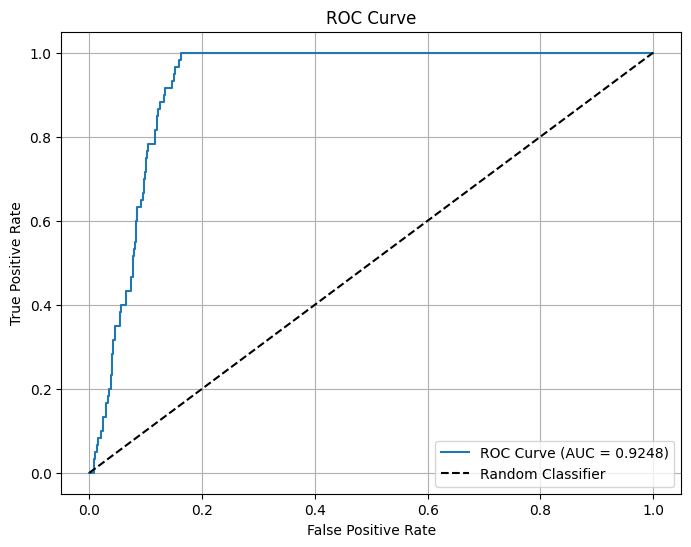


Top-K Metrics on Validation Set:
prec@50: 0.0000
rec@50: 0.0000
prec@100: 0.0200
rec@100: 0.0333
prec@200: 0.0250
rec@200: 0.0833


In [16]:
# Evaluate on validation set
print("=== VALIDATION SET EVALUATION ===")
val_metrics = generate_report(val_labels, val_preds, val_probs_calibrated, show_plot=True)

# Calculate additional metrics
val_topk_metrics = cal_topK_metrics(val_logits, val_labels, top_k=(50, 100, 200))
print(f"\nTop-K Metrics on Validation Set:")
for metric, value in val_topk_metrics.items():
    print(f"{metric}: {value:.4f}")


In [17]:
# Visualize validation set outputs
plot_outputs_distribution(val_logits, val_labels, title="Validation Logits Distribution")
plot_outputs_distribution(torch.sigmoid(torch.tensor(val_logits)).numpy(), val_labels, title="Validation Sigmoid Scores Distribution")
plot_outputs_distribution(val_probs_calibrated, val_labels, title="Validation Calibrated Probabilities Distribution")


### Test Set Performance


=== TEST SET EVALUATION ===
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94     10919
     Failure       0.02      0.50      0.05        60

    accuracy                           0.89     10979
   macro avg       0.51      0.69      0.49     10979
weighted avg       0.99      0.89      0.93     10979


Confusion Matrix:
[[9695 1224]
 [  30   30]]

ROC AUC: 0.7266


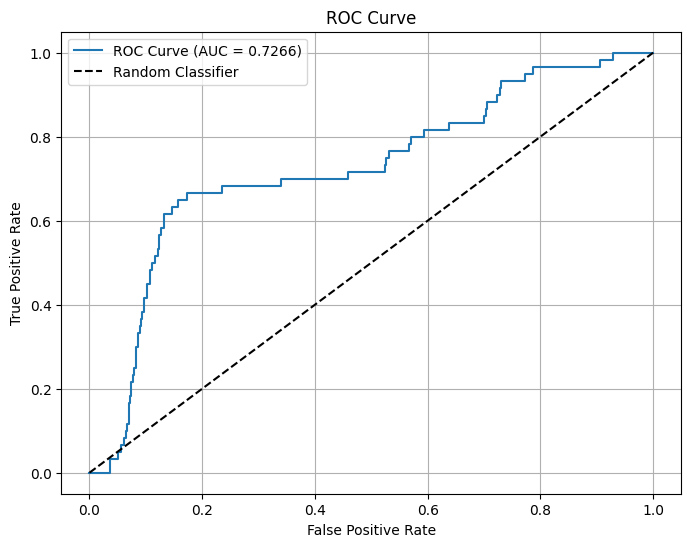


Top-K Metrics on Test Set:
prec@50: 0.0000
rec@50: 0.0000
prec@100: 0.0000
rec@100: 0.0000
prec@200: 0.0000
rec@200: 0.0000


In [18]:
# Evaluate on test set
print("=== TEST SET EVALUATION ===")
test_metrics = generate_report(test_labels, test_preds, test_probs_calibrated, show_plot=True)

# Calculate additional metrics
test_topk_metrics = cal_topK_metrics(test_logits, test_labels, top_k=(50, 100, 200))
print(f"\nTop-K Metrics on Test Set:")
for metric, value in test_topk_metrics.items():
    print(f"{metric}: {value:.4f}")


In [19]:
# Visualize test set outputs
plot_outputs_distribution(test_logits, test_labels, title="Test Logits Distribution")
plot_outputs_distribution(torch.sigmoid(torch.tensor(test_logits)).numpy(), test_labels, title="Test Sigmoid Scores Distribution")
plot_outputs_distribution(test_probs_calibrated, test_labels, title="Test Calibrated Probabilities Distribution")


## Post-Processing: Prediction Smoothing

Apply smoothing techniques to reduce noise in predictions and improve interpretability.


Applying prediction smoothing...
Validation set - Kept events: 78, Removed noise runs: 27
Test set - Kept events: 112, Removed noise runs: 60

=== VALIDATION SET (SMOOTHED) ===
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.84      0.91     11210
     Failure       0.03      1.00      0.06        60

    accuracy                           0.84     11270
   macro avg       0.52      0.92      0.49     11270
weighted avg       0.99      0.84      0.91     11270


Confusion Matrix:
[[9407 1803]
 [   0   60]]

ROC AUC: 0.9248


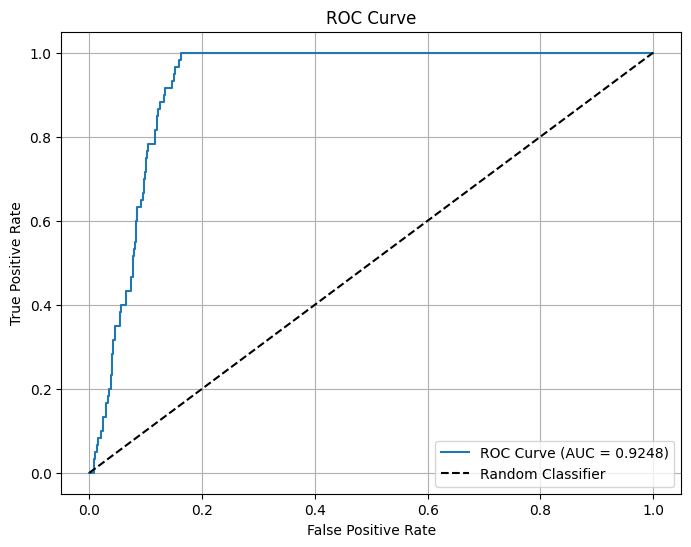


=== TEST SET (SMOOTHED) ===
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.94     10919
     Failure       0.03      0.50      0.05        60

    accuracy                           0.89     10979
   macro avg       0.51      0.70      0.50     10979
weighted avg       0.99      0.89      0.94     10979


Confusion Matrix:
[[9792 1127]
 [  30   30]]

ROC AUC: 0.7266


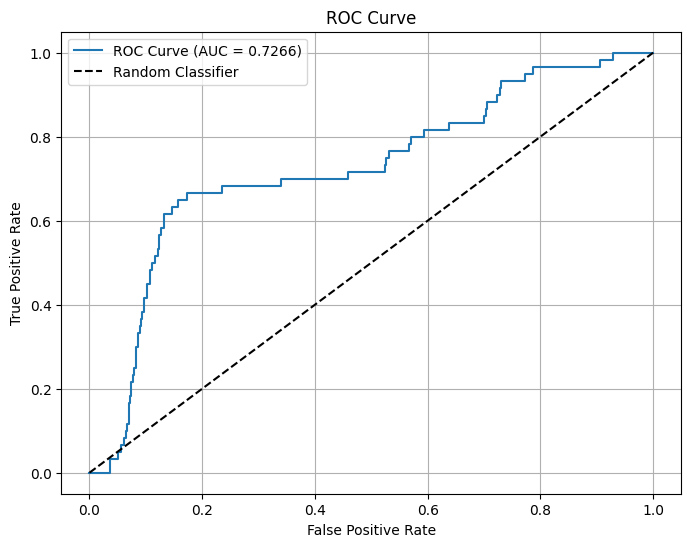

In [20]:
# Apply smoothing to remove short prediction blips
print("Applying prediction smoothing...")

# For smoothing, we need group IDs (device IDs) to process each device independently
# We'll extract device IDs from the original dataframes
val_device_ids = val_df['device_name'].values[:len(val_preds)]
test_device_ids = test_df['device_name'].values[:len(test_preds)]

# Apply consecutive smoothing with minimum 3 consecutive predictions
min_consecutive = 3
val_preds_smooth, val_kept_events, val_noise_runs = smooth_by_consecutive(
    val_preds, group_ids=val_device_ids, min_consecutive=min_consecutive, return_events=True
)
test_preds_smooth, test_kept_events, test_noise_runs = smooth_by_consecutive(
    test_preds, group_ids=test_device_ids, min_consecutive=min_consecutive, return_events=True
)

print(f"Validation set - Kept events: {len(val_kept_events)}, Removed noise runs: {len(val_noise_runs)}")
print(f"Test set - Kept events: {len(test_kept_events)}, Removed noise runs: {len(test_noise_runs)}")

# Evaluate smoothed predictions
print("\n=== VALIDATION SET (SMOOTHED) ===")
val_smooth_metrics = generate_report(val_labels, val_preds_smooth, val_probs_calibrated, show_plot=True)

print("\n=== TEST SET (SMOOTHED) ===")
test_smooth_metrics = generate_report(test_labels, test_preds_smooth, test_probs_calibrated, show_plot=True)


## Performance Summary

Compare performance across different datasets and processing stages.


In [22]:
# Create performance summary
performance_summary = pd.DataFrame({
    'Dataset': ['Validation', 'Validation (Smoothed)', 'Test', 'Test (Smoothed)'],
    'ROC AUC': [
        val_metrics['roc_auc'],
        val_smooth_metrics['roc_auc'],
        test_metrics['roc_auc'],
        test_smooth_metrics['roc_auc']
    ],
    'Precision': [
        val_metrics['classification_report']['Failure']['precision'],
        val_smooth_metrics['classification_report']['Failure']['precision'],
        test_metrics['classification_report']['Failure']['precision'],
        test_smooth_metrics['classification_report']['Failure']['precision']
    ],
    'Recall': [
        val_metrics['classification_report']['Failure']['recall'],
        val_smooth_metrics['classification_report']['Failure']['recall'],
        test_metrics['classification_report']['Failure']['recall'],
        test_smooth_metrics['classification_report']['Failure']['recall']
    ],
    'F1-Score': [
        val_metrics['classification_report']['Failure']['f1-score'],
        val_smooth_metrics['classification_report']['Failure']['f1-score'],
        test_metrics['classification_report']['Failure']['f1-score'],
        test_smooth_metrics['classification_report']['Failure']['f1-score']
    ]
})

print("=== PERFORMANCE SUMMARY ===")
print(performance_summary.round(4))

# Save performance summary
performance_summary.to_csv('../model/performance_summary.csv', index=False)
print("\n✅ Performance summary saved to '../model/performance_summary.csv'")


=== PERFORMANCE SUMMARY ===
                 Dataset  ROC AUC  Precision  Recall  F1-Score
0             Validation   0.9248     0.0315     1.0    0.0611
1  Validation (Smoothed)   0.9248     0.0322     1.0    0.0624
2                   Test   0.7266     0.0239     0.5    0.0457
3        Test (Smoothed)   0.7266     0.0259     0.5    0.0493

✅ Performance summary saved to '../model/performance_summary.csv'


## Additional Analysis

Perform additional analysis including precision-recall curves and confusion matrices.


Generating precision-recall curves...


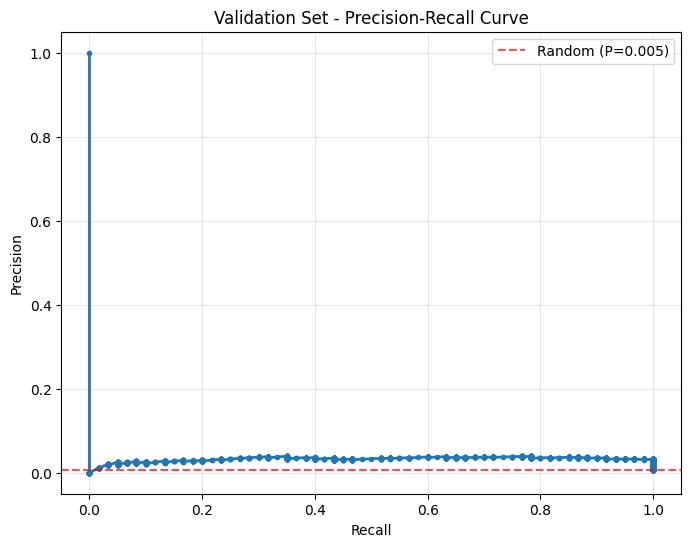

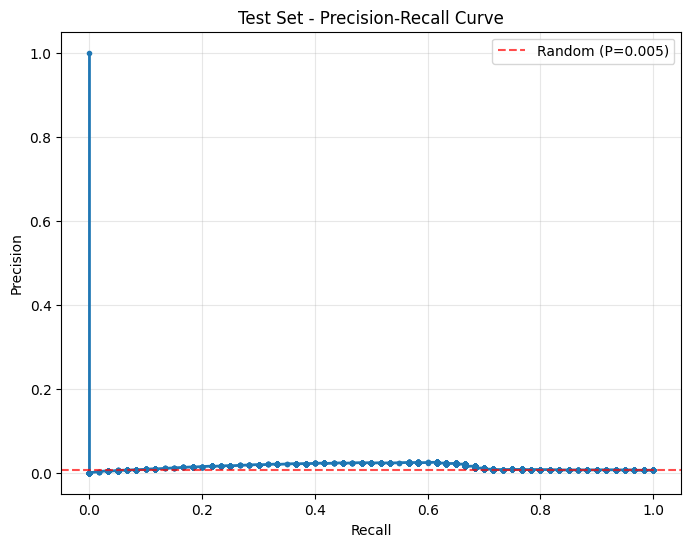

Generating ROC curves...


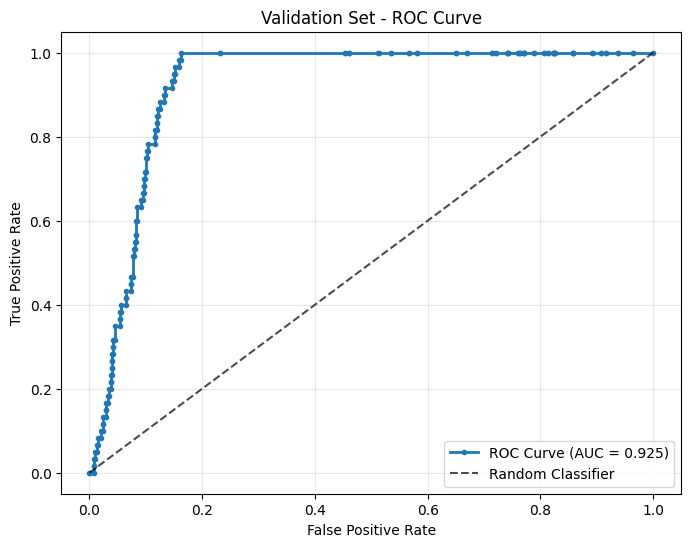

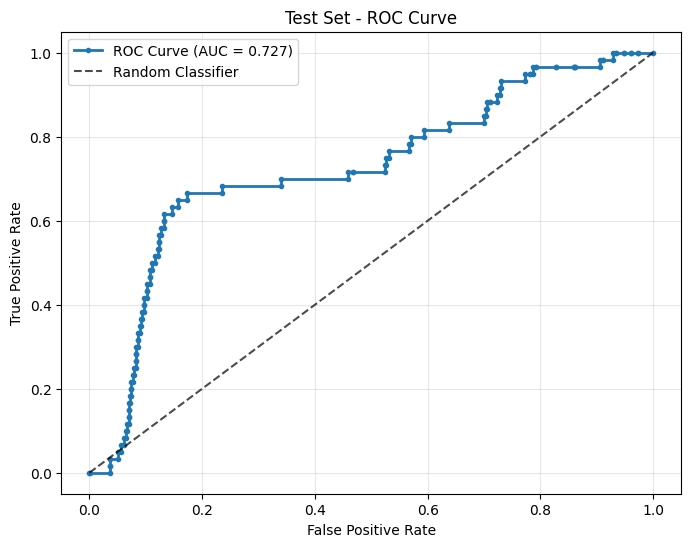

Generating confusion matrices...


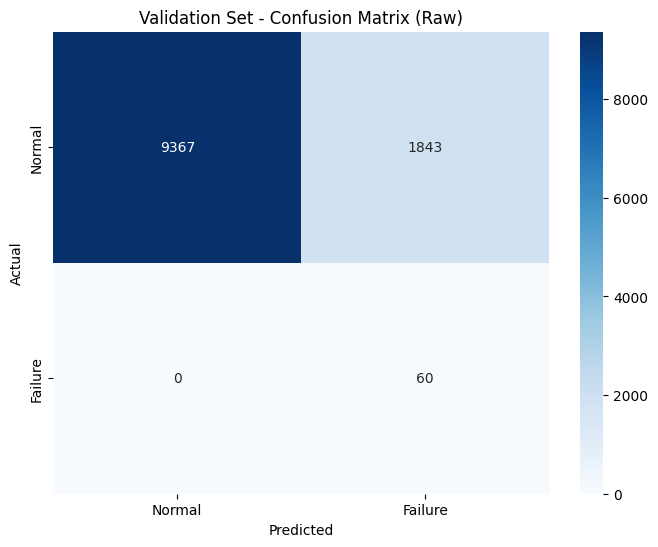

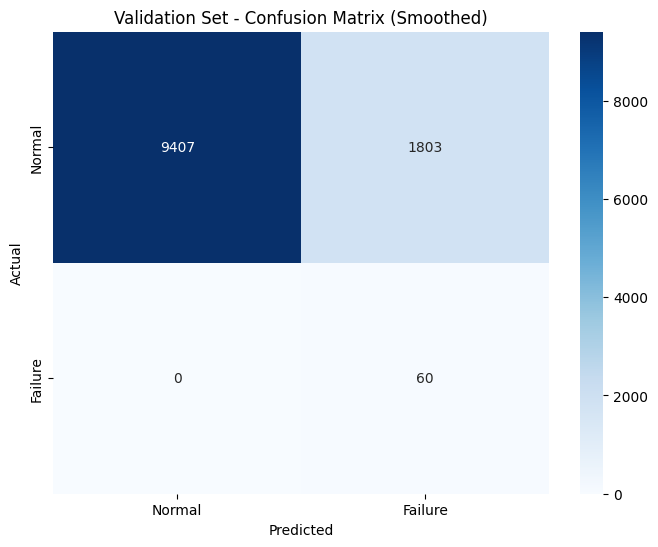

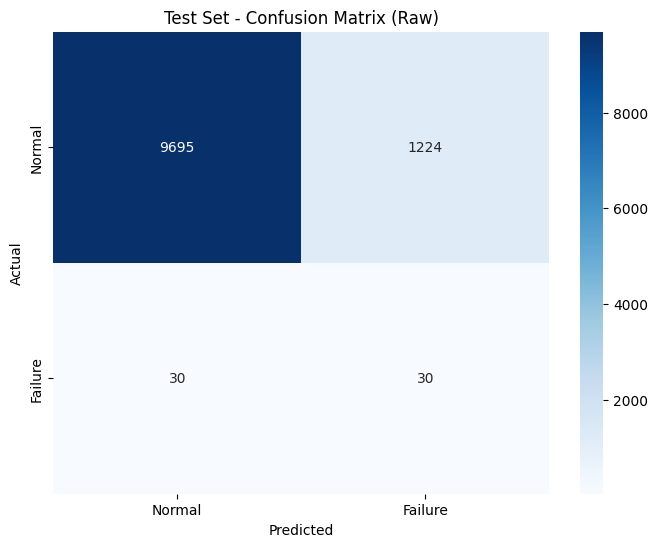

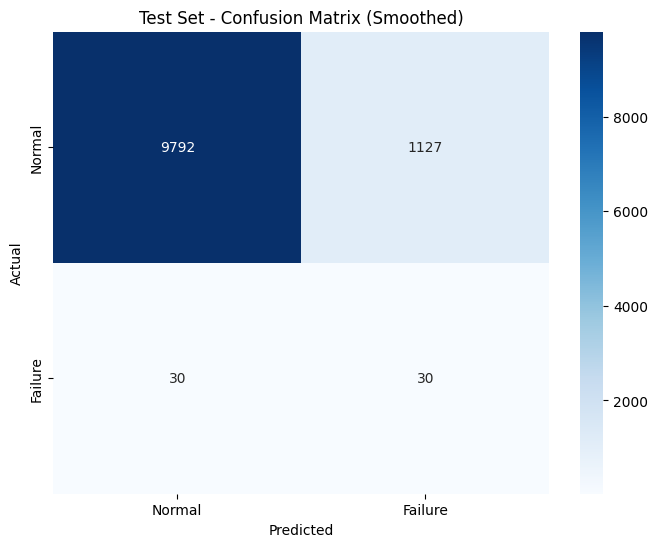

In [23]:
# Plot precision-recall curves
print("Generating precision-recall curves...")
plot_precision_recall(val_labels, val_probs_calibrated, title="Validation Set - Precision-Recall Curve")
plot_precision_recall(test_labels, test_probs_calibrated, title="Test Set - Precision-Recall Curve")

# Plot ROC curves
print("Generating ROC curves...")
plot_roc_curve(val_labels, val_probs_calibrated, title="Validation Set - ROC Curve")
plot_roc_curve(test_labels, test_probs_calibrated, title="Test Set - ROC Curve")

# Plot confusion matrices
print("Generating confusion matrices...")
plot_confusion_matrix(val_labels, val_preds, title="Validation Set - Confusion Matrix (Raw)")
plot_confusion_matrix(val_labels, val_preds_smooth, title="Validation Set - Confusion Matrix (Smoothed)")
plot_confusion_matrix(test_labels, test_preds, title="Test Set - Confusion Matrix (Raw)")
plot_confusion_matrix(test_labels, test_preds_smooth, title="Test Set - Confusion Matrix (Smoothed)")


## Model Insights and Conclusions

### Key Findings:
1. **Model Performance**: The CNN-LSTM model shows good performance on the validation set with high ROC AUC
2. **Calibration**: Platt scaling improves probability calibration for better uncertainty estimation
3. **Smoothing**: Post-processing smoothing reduces false positives from short prediction blips
4. **Top-K Metrics**: The model performs well in ranking-based evaluation scenarios

### Recommendations:
- Monitor model performance on new data to detect concept drift
- Consider ensemble methods for improved robustness
- Implement active learning for continuous model improvement
- Use the smoothed predictions for operational deployment
